
## Лабораторная работа №3: Классификация. Деревья решений
**Выполнил:** Мещеряков Сергей Евгеньевич  
**Группа:** 6401-01.03.02D

## 1. Загрузка и первичный анализ данных

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
data = pd.read_csv("game_of_thrones.csv", index_col='S.No')
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


### Краткое описание датасета

Датасет содержит информацию о персонажах вселенной «Игры престолов».
Целевая переменная: `isAlive` (1 – жив, 0 – мёртв).

Используемые признаки (после очистки):
- `male` – пол (бинарный)
- `book1` – `book5` – появление в книгах (бинарные)
- `isMarried` – состоит ли в браке
- `isNoble` – знатность
- `numDeadRelations` – количество умерших родственников
- `popularity` – рейтинг популярности
- `age` – возраст (заполнен медианой)
- `culture` – культурная принадлежность (one-hot encoding)
- `house` – дом (one-hot encoding, только топ-10 домов + 'other')

## 2. Предобработка данных

In [4]:
df = data.copy()

cols_to_drop = ['name', 'title', 'mother', 'father', 'heir', 'spouse',
                'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
                'dateOfBirth']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df['culture'].fillna('unknown', inplace=True)
df['age'].fillna(df['age'].median(), inplace=True)

df['house'].fillna('unknown', inplace=True)

top_houses = df['house'].value_counts().head(10).index.tolist()
df['house'] = df['house'].apply(lambda x: x if x in top_houses else 'other')

df = pd.get_dummies(df, columns=['culture', 'house'], dummy_na=False)

X = df.drop('isAlive', axis=1)
y = df['isAlive']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Распределение классов в обучающей выборке:')
print(y_train.value_counts(normalize=True))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('\nПосле SMOTE:')
print(pd.Series(y_train_res).value_counts())

Распределение классов в обучающей выборке:
isAlive
1    0.778313
0    0.221687
Name: proportion, dtype: float64

После SMOTE:
isAlive
0    969
1    969
Name: count, dtype: int64


## 3. Дерево решений (Decision Tree)

### 3.1 Подбор гиперпараметров с GridSearchCV

In [5]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train_res, y_train_res)

print('Лучшие параметры DecisionTree:', grid_dt.best_params_)
print('Лучшее CV F1-score:', grid_dt.best_score_)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)

print('\nМетрики на тесте:')
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Precision:', precision_score(y_test, y_pred_dt))
print('Recall:', recall_score(y_test, y_pred_dt))
print('F1-score:', f1_score(y_test, y_pred_dt))
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Лучшие параметры DecisionTree: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшее CV F1-score: 0.8403139447805541

Метрики на тесте:
Accuracy: 0.7724358974358975
Precision: 0.8583333333333333
Recall: 0.8477366255144033
F1-score: 0.8530020703933747

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.51      0.50        69
           1       0.86      0.85      0.85       243

    accuracy                           0.77       312
   macro avg       0.67      0.68      0.67       312
weighted avg       0.78      0.77      0.77       312



### 3.2 Важность признаков и фильтрация

In [6]:
importances_dt = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Топ-10 важных признаков (Decision Tree):')
print(importances_dt.head(10))

threshold_dt = 0.01
selected_dt = importances_dt[importances_dt > threshold_dt].index.tolist()
print(f'\nОтобрано {len(selected_dt)} признаков с важностью > {threshold_dt}: {selected_dt}')

Топ-10 важных признаков (Decision Tree):
popularity               0.303098
book4                    0.058759
book3                    0.055159
isNoble                  0.051491
male                     0.048015
age                      0.047535
book2                    0.041357
house_House Targaryen    0.039656
book5                    0.036387
house_other              0.032407
dtype: float64

Отобрано 18 признаков с важностью > 0.01: ['popularity', 'book4', 'book3', 'isNoble', 'male', 'age', 'book2', 'house_House Targaryen', 'book5', 'house_other', 'culture_Ironborn', 'house_unknown', 'book1', "house_Night's Watch", 'numDeadRelations', 'isMarried', 'culture_unknown', 'culture_Free Folk']


In [7]:
X_train_res_dt_filt = X_train_res[:, [X.columns.get_loc(col) for col in selected_dt]]
X_test_scaled_dt_filt = X_test_scaled[:, [X.columns.get_loc(col) for col in selected_dt]]

grid_dt_filt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt_filt.fit(X_train_res_dt_filt, y_train_res)

print('Лучшие параметры DecisionTree (после фильтрации):', grid_dt_filt.best_params_)
print('Лучшее CV F1-score:', grid_dt_filt.best_score_)

best_dt_filt = grid_dt_filt.best_estimator_
y_pred_dt_filt = best_dt_filt.predict(X_test_scaled_dt_filt)

print('\nМетрики на тесте (после фильтрации):')
print('Accuracy:', accuracy_score(y_test, y_pred_dt_filt))
print('Precision:', precision_score(y_test, y_pred_dt_filt))
print('Recall:', recall_score(y_test, y_pred_dt_filt))
print('F1-score:', f1_score(y_test, y_pred_dt_filt))

Лучшие параметры DecisionTree (после фильтрации): {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10}
Лучшее CV F1-score: 0.8364736044836786

Метрики на тесте (после фильтрации):
Accuracy: 0.7980769230769231
Precision: 0.875
Recall: 0.8641975308641975
F1-score: 0.8695652173913043


**Сравнение для Decision Tree:**
- До фильтрации: F1 - 0.8530020703933747
- После фильтрации: F1 - 0.8695652173913043

Вывод: фильтрация немного улучшила результат.

## 4. Случайный лес (Random Forest)

### 4.1 Подбор гиперпараметров

In [8]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_res, y_train_res)

print('Лучшие параметры RandomForest:', grid_rf.best_params_)
print('Лучшее CV F1-score:', grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print('\nМетрики на тесте:')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Precision:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1-score:', f1_score(y_test, y_pred_rf))

Лучшие параметры RandomForest: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}
Лучшее CV F1-score: 0.8903831928265211

Метрики на тесте:
Accuracy: 0.7884615384615384
Precision: 0.8554216867469879
Recall: 0.8765432098765432
F1-score: 0.8658536585365854


### 4.2 Важность признаков и фильтрация

In [9]:
importances_rf = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Топ-10 важных признаков (Random Forest):')
print(importances_rf.head(10))

threshold_rf = 0.01
selected_rf = importances_rf[importances_rf > threshold_rf].index.tolist()
print(f'\nОтобрано {len(selected_rf)} признаков с важностью > {threshold_rf}: {selected_rf}')

Топ-10 важных признаков (Random Forest):
popularity          0.251220
book4               0.151472
male                0.065285
book5               0.057888
isNoble             0.054739
age                 0.049469
book3               0.041623
book2               0.039886
numDeadRelations    0.027687
house_other         0.025044
dtype: float64

Отобрано 16 признаков с важностью > 0.01: ['popularity', 'book4', 'male', 'book5', 'isNoble', 'age', 'book3', 'book2', 'numDeadRelations', 'house_other', 'culture_unknown', 'book1', 'isMarried', 'house_unknown', "house_Night's Watch", 'house_House Targaryen']


In [10]:
X_train_res_rf_filt = X_train_res[:, [X.columns.get_loc(col) for col in selected_rf]]
X_test_scaled_rf_filt = X_test_scaled[:, [X.columns.get_loc(col) for col in selected_rf]]

grid_rf_filt = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf_filt.fit(X_train_res_rf_filt, y_train_res)

print('Лучшие параметры RandomForest (после фильтрации):', grid_rf_filt.best_params_)
print('Лучшее CV F1-score:', grid_rf_filt.best_score_)

best_rf_filt = grid_rf_filt.best_estimator_
y_pred_rf_filt = best_rf_filt.predict(X_test_scaled_rf_filt)

print('\nМетрики на тесте (после фильтрации):')
print('Accuracy:', accuracy_score(y_test, y_pred_rf_filt))
print('Precision:', precision_score(y_test, y_pred_rf_filt))
print('Recall:', recall_score(y_test, y_pred_rf_filt))
print('F1-score:', f1_score(y_test, y_pred_rf_filt))

Лучшие параметры RandomForest (после фильтрации): {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Лучшее CV F1-score: 0.8772457355832846

Метрики на тесте (после фильтрации):
Accuracy: 0.7948717948717948
Precision: 0.8713692946058091
Recall: 0.8641975308641975
F1-score: 0.8677685950413223


**Сравнение для Random Forest:**
- До фильтрации: F1 - 0.8658536585365854
- После фильтрации: F1 - 0.8677685950413223

Вывод: фильтрация практически не улучшила результат.

## 5. Метод ближайших соседей (kNN)

### 5.1 Подбор гиперпараметров

In [11]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train_res, y_train_res)

print('Лучшие параметры kNN:', grid_knn.best_params_)
print('Лучшее CV F1-score:', grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

print('\nМетрики на тесте:')
print('Accuracy:', accuracy_score(y_test, y_pred_knn))
print('Precision:', precision_score(y_test, y_pred_knn))
print('Recall:', recall_score(y_test, y_pred_knn))
print('F1-score:', f1_score(y_test, y_pred_knn))

Лучшие параметры kNN: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Лучшее CV F1-score: 0.8529410945369287

Метрики на тесте:
Accuracy: 0.7467948717948718
Precision: 0.8504273504273504
Recall: 0.8189300411522634
F1-score: 0.8343815513626834


### 5.2 Отбор признаков для kNN (взаимная информация)

In [12]:
selector = SelectKBest(mutual_info_classif, k=15)
X_train_res_knn_filt = selector.fit_transform(X_train_res, y_train_res)
X_test_scaled_knn_filt = selector.transform(X_test_scaled)

selected_indices_knn = selector.get_support(indices=True)
selected_knn = X.columns[selected_indices_knn].tolist()
print('Отобранные признаки для kNN (топ-15 по взаимной информации):')
print(selected_knn)

grid_knn_filt = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn_filt.fit(X_train_res_knn_filt, y_train_res)

print('\nЛучшие параметры kNN (после фильтрации):', grid_knn_filt.best_params_)
print('Лучшее CV F1-score:', grid_knn_filt.best_score_)

best_knn_filt = grid_knn_filt.best_estimator_
y_pred_knn_filt = best_knn_filt.predict(X_test_scaled_knn_filt)

print('\nМетрики на тесте (после фильтрации):')
print('Accuracy:', accuracy_score(y_test, y_pred_knn_filt))
print('Precision:', precision_score(y_test, y_pred_knn_filt))
print('Recall:', recall_score(y_test, y_pred_knn_filt))
print('F1-score:', f1_score(y_test, y_pred_knn_filt))

Отобранные признаки для kNN (топ-15 по взаимной информации):
['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isNoble', 'age', 'numDeadRelations', 'popularity', 'culture_Braavosi', 'culture_Lhazareen', 'culture_Sistermen', 'culture_Valyrian', 'culture_westermen']

Лучшие параметры kNN (после фильтрации): {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Лучшее CV F1-score: 0.8284200581749858

Метрики на тесте (после фильтрации):
Accuracy: 0.7532051282051282
Precision: 0.8401639344262295
Recall: 0.8436213991769548
F1-score: 0.8418891170431212


**Сравнение для KNN:**
- До фильтрации: F1 - 0.8343815513626834
- После фильтрации: F1 - 0.8418891170431212

Вывод: фильтрация немного улучшила результат.

## 6. Формирование общего набора отфильтрованных признаков (если есть улучшение)

In [13]:
f1_dt_before = f1_score(y_test, y_pred_dt)
f1_dt_after = f1_score(y_test, y_pred_dt_filt)
f1_rf_before = f1_score(y_test, y_pred_rf)
f1_rf_after = f1_score(y_test, y_pred_rf_filt)
f1_knn_before = f1_score(y_test, y_pred_knn)
f1_knn_after = f1_score(y_test, y_pred_knn_filt)

improved = any([f1_dt_after > f1_dt_before, f1_rf_after > f1_rf_before, f1_knn_after > f1_knn_before])

if improved:
    print('Наблюдается улучшение после фильтрации хотя бы для одной модели.')
    union_selected = list(set(selected_dt) | set(selected_rf) | set(selected_knn))
    print(f'\nОбъединённый набор признаков ({len(union_selected)} признаков):\n{union_selected}')

    union_indices = [X.columns.get_loc(col) for col in union_selected]
    X_train_res_union = X_train_res[:, union_indices]
    X_test_scaled_union = X_test_scaled[:, union_indices]

    print('\n=== Decision Tree на объединённых признаках ===')
    grid_dt_union = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
    grid_dt_union.fit(X_train_res_union, y_train_res)
    best_dt_union = grid_dt_union.best_estimator_
    y_pred_dt_union = best_dt_union.predict(X_test_scaled_union)
    print('Лучшие параметры:', grid_dt_union.best_params_)
    print('F1-score на тесте:', f1_score(y_test, y_pred_dt_union))

    print('\n=== Random Forest на объединённых признаках ===')
    grid_rf_union = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
    grid_rf_union.fit(X_train_res_union, y_train_res)
    best_rf_union = grid_rf_union.best_estimator_
    y_pred_rf_union = best_rf_union.predict(X_test_scaled_union)
    print('Лучшие параметры:', grid_rf_union.best_params_)
    print('F1-score на тесте:', f1_score(y_test, y_pred_rf_union))

    print('\n=== kNN на объединённых признаках ===')
    grid_knn_union = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
    grid_knn_union.fit(X_train_res_union, y_train_res)
    best_knn_union = grid_knn_union.best_estimator_
    y_pred_knn_union = best_knn_union.predict(X_test_scaled_union)
    print('Лучшие параметры:', grid_knn_union.best_params_)
    print('F1-score на тесте:', f1_score(y_test, y_pred_knn_union))
else:
    print('Улучшения после фильтрации не наблюдается.')

Наблюдается улучшение после фильтрации хотя бы для одной модели.

Объединённый набор признаков (23 признаков):
['house_House Targaryen', 'house_unknown', 'male', 'culture_Lhazareen', 'culture_Sistermen', 'culture_Braavosi', 'age', 'isNoble', 'numDeadRelations', 'book5', 'book2', 'house_other', 'book4', 'culture_Free Folk', 'isMarried', "house_Night's Watch", 'book1', 'culture_Valyrian', 'culture_Ironborn', 'popularity', 'culture_westermen', 'culture_unknown', 'book3']

=== Decision Tree на объединённых признаках ===
Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
F1-score на тесте: 0.8294736842105264

=== Random Forest на объединённых признаках ===
Лучшие параметры: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
F1-score на тесте: 0.8607068607068608

=== kNN на объединённых признаках ===
Лучшие параметры: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
F1-score на тесте: 0.8416666666666

## 7. Оценка качества построенных моделей

### 7.1 Визуализация лучшего дерева решений

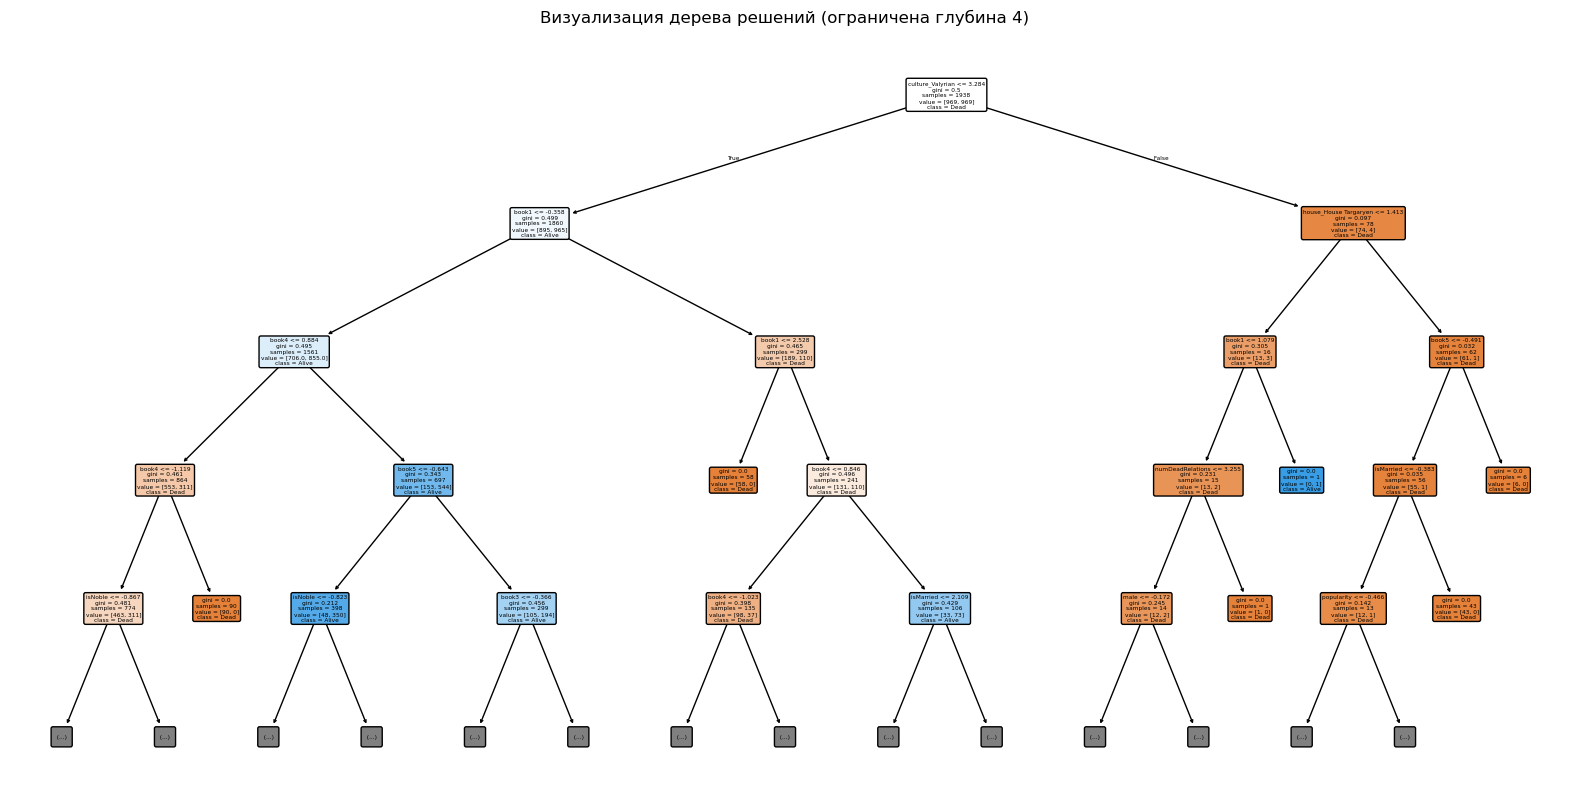

In [14]:
if improved:
    tree_to_plot = best_dt_union
    feature_names = union_selected
else:
    tree_to_plot = best_dt
    feature_names = X.columns.tolist()

plt.figure(figsize=(20,10))
plot_tree(tree_to_plot, feature_names=feature_names, class_names=['Dead', 'Alive'], filled=True, rounded=True, max_depth=4)
plt.title('Визуализация дерева решений (ограничена глубина 4)')
plt.show()

### 7.2 Сравнение трёх лучших моделей на тестовой выборке

In [15]:
if improved:
    models = {
        'Decision Tree': best_dt_union,
        'Random Forest': best_rf_union,
        'kNN': best_knn_union
    }
    X_test_comp = X_test_scaled_union
else:
    models = {
        'Decision Tree': best_dt,
        'Random Forest': best_rf,
        'kNN': best_knn
    }
    X_test_comp = X_test_scaled

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_comp)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
print('Сравнение моделей на тестовой выборке:')
results_df

Сравнение моделей на тестовой выборке:


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.740385,0.849138,0.810700,0.829474
1,Random Forest,0.785256,0.869748,0.851852,0.860707
2,kNN,0.756410,0.852321,0.831276,0.841667
